In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.utils import resample
from collections import Counter

Original class distribution: Counter({np.int64(0): 894, np.int64(1): 106})


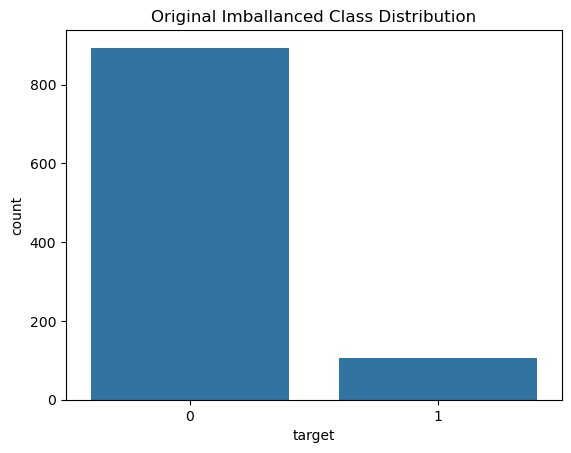

In [10]:
# 1. create imbalanced dataset
x,y =make_classification(n_classes=2, class_sep=2,
                        weights=[0.9, 0.1], # 90% vs 10%)
                         n_informative=3, n_redundant=0,
                         n_features=5, n_samples=1000,
                         random_state=42)
df = pd.DataFrame(x, columns=[f"feature_{i}"
                            for i in range(x.shape[1])])
df['target']=y
print("Original class distribution:", Counter(y))
sns.countplot(x=df['target'])
plt.title("Original Imballanced Class Distribution")
plt.show()

In [14]:
# 2. Random Over Sampling (with sklearn resample)

df_majority = df[df['target']== 0]
df_minority = df[df['target']== 1]

df_minority_oversampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)
df_over = pd.concat([df_majority, df_minority_oversampled])
print("After Over Sampling:", Counter(df_over['target']))

After Over Sampling: Counter({0: 894, 1: 894})


In [15]:
# 3. Random Under Sampling

df_majority_undersampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)
df_under = pd.concat([df_majority_undersampled, df_minority])
print("After Under Sampling:", Counter(df_under['target']))

After Under Sampling: Counter({0: 106, 1: 106})


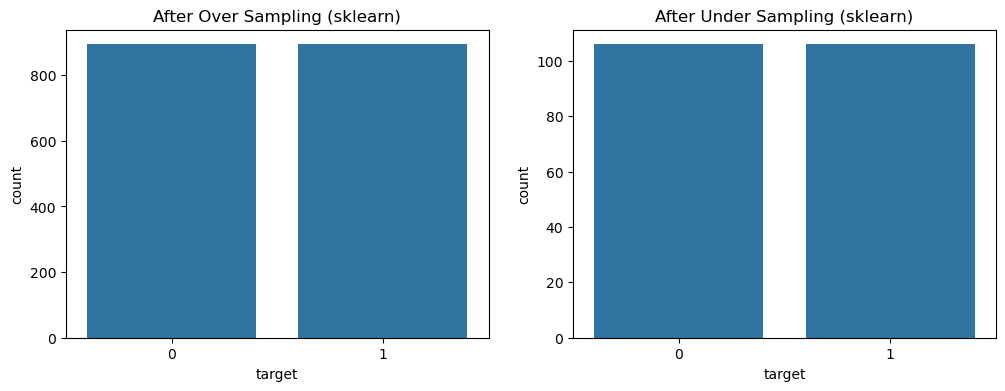

In [16]:
# 4. visualization
fif, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x=df_over['target'], ax=axes[0])
axes[0].set_title("After Over Sampling (sklearn)")

sns.countplot(x=df_under['target'], ax=axes[1])
axes[1].set_title("After Under Sampling (sklearn)")
plt.show()